In [2]:
import pandas as pd
import numpy as np
import shap
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

In [3]:
# "Based [kernel] SHAPiro doesn't care about your feelings"

In [24]:
df = pd.read_csv('incident_records.csv')
df = df.sort_values('nkill', ascending=False)
df = df.drop([340, 341, 342, 343])              # Dropped Sep 11, 2001 as an extreme outlier

cols_to_join = ['iyear','imonth']
df['date'] = df[cols_to_join].astype(str).agg('-'.join, axis=1)


df['casualties'] = df['nkill'].apply(lambda x: 1 if x > 0 else 0)

df.head()

,iyear,imonth,iday,region_txt,country_txt,latitude,longitude,nwound,nkill,date,casualties
479,2002,5,2,South America,Colombia,6.521111,-76.972222,80.0,119.0,2002-5,1
2954,2017,10,1,North America,United States,36.082645,-115.135925,851.0,59.0,2017-10,1
2601,2016,6,12,North America,United States,28.519601,-81.376794,53.0,50.0,2016-6,1
1797,2013,1,31,North America,Mexico,19.371887,-99.086624,101.0,37.0,2013-1,1
621,2003,2,7,South America,Colombia,4.667128,-74.106056,162.0,32.0,2003-2,1


In [32]:
df['country_txt'].value_counts()

country_txt
Colombia         1978
United States     468
Mexico            115
Chile              91
Paraguay           74
Peru               67
Venezuela          52
Canada             52
Ecuador            30
Brazil             24
Argentina          23
Bolivia             9
Guyana              8
Uruguay             2
Name: count, dtype: int64

In [34]:
feat_cols = ['iyear','imonth','latitude', 'longitude', 'nwound']

X = df[feat_cols]
y = df['casualties']

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2)

<Axes: xlabel='imonth'>

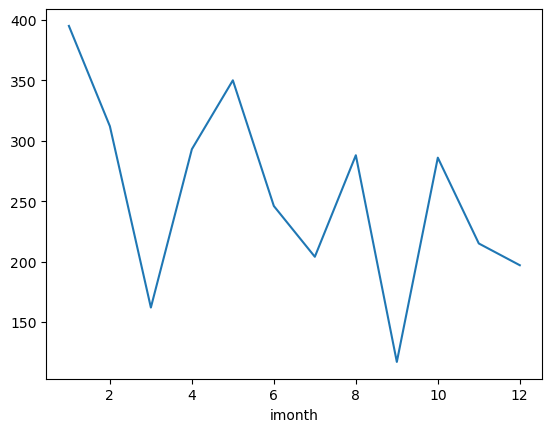

In [35]:
import matplotlib.pyplot as plt
df.groupby('imonth')['nkill'].sum().plot()

# Create the model

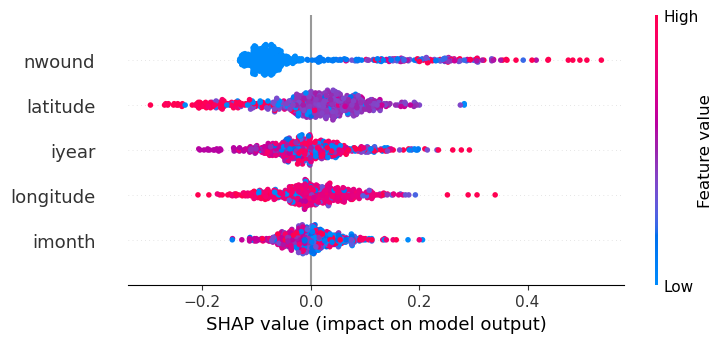

In [37]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Build the explainer once, from the trained model
explainer = shap.TreeExplainer(rf)
shap_values = explainer(X_test)

shap.plots.beeswarm(shap_values[:, :, 1])

In [44]:
X_test

,iyear,imonth,latitude,longitude,nwound
2227,2014,10,45.423571,-75.700909,3.0
24,2000,2,-2.170832,-79.922359,1.0
2741,2017,1,41.842602,-87.681229,1.0
815,2005,7,4.028460,-74.635520,5.0
2035,2014,4,3.017089,-76.641926,1.0
...,...,...,...,...,...
118,2000,10,3.429344,-76.516037,7.0
2306,2015,2,41.151766,-81.348654,0.0
1500,2011,2,6.949733,-75.119527,1.0
1973,2014,1,8.868790,-73.194094,0.0


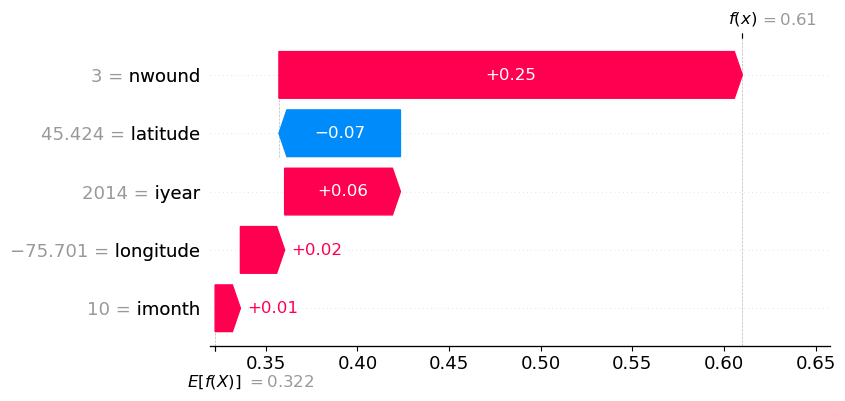

In [43]:
shap.plots.waterfall(shap_values[0, :, 1])